# Итоговый проект: Модель кредитного риск-менеджмента

## Прогнозирование дефолта заёмщика

**Автор:** Юлия Прохорова

**Курс:** Machine Learning Junior

**Задача:** бинарная классификация — предсказать, допустит ли клиент дефолт по кредиту

**Метрика качества:** ROC-AUC (порог >= 0.75)

---

# 1. Business Understanding

___

## 1.1. Цель проекта

Банки выдают кредиты, но не все клиенты их возвращают. Если вовремя понять, кто может не заплатить, можно избежать убытков.

**Моя задача** — обучить модель, которая по истории клиента предскажет, допустит ли он дефолт (просрочку больше 90 дней).

Это задача **бинарной классификации**:  
- **1** — клиент не выполнит обязательства (дефолт)  
- **0** — всё в порядке

## 1.2. Бизнес-ценность

Если модель сможет заранее предсказывать дефолт, банк получит несколько преимуществ:

- **Снижение рисков** — меньше денег "уйдёт в минус" из-за невозвратов
- **Экономия времени** — не нужно проверять каждого клиента вручную
- **Более быстрые решения** — автоматизация кредитного скоринга

Чем точнее модель, тем больше денег банк сэкономит (или заработает).  
**Моя цель — сделать модель полезной.**

## 1.3. Формализация задачи ML

**Тип задачи:** бинарная классификация

**Класс 1:** дефолт (просрочка 90+ дней)

**Класс 0:** надежный клиент

## 1.4. Метрика качества

**ROC-AUC**

**Причина:** дисбаланс классов (3.55% default)

## 1.5. Ограничения задачи

- память 12–16 GB (Colab)
- нельзя загрузить весь dataset
- требуется batch / chunk processing
- обязательна агрегация по id

# 2. Data Understanding (Понимание данных)

___

## 2.1. Загрузка и первичный осмотр данных кредитной истории

In [21]:
import os
import glob
import pandas as pd
import dask.dataframe as dd
from google.colab import drive

# Монтирую Google Диск для доступа к файлам проекта
drive.mount('/content/drive')

# Жестко фиксирую точный и проверенный путь к данным
train_path = "/content/drive/MyDrive/Итоговый проект: Модель кредитного риск-менеджмента/train_data"

# Загружаю датасет в ленивом режиме через Dask DataFrame
df = dd.read_parquet(train_path)

print("Окружение успешно настроено")
print(f"Путь к данным: {train_path}")
print(f"Количество исходных признаков в датасете: {len(df.columns)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Окружение успешно настроено
Путь к данным: /content/drive/MyDrive/Итоговый проект: Модель кредитного риск-менеджмента/train_data
Количество исходных признаков в датасете: 61


## 2.2. Первичный осмотр и проверка структуры данных

In [22]:
# Смотрю на первые три строки датасета для ознакомления с признаками
print("Пример исходных данных кредитной истории:")
display(df.head(3))

# Вывожу типы данных всех колонок исходного датасета
print("\nИсходные типы данных в датасете:")
print(df.dtypes)

Пример исходных данных кредитной истории:


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,0,4,1,2,3,1,1,1



Исходные типы данных в датасете:
id                         int64
rn                         int64
pre_since_opened           int64
pre_since_confirmed        int64
pre_pterm                  int64
                           ...  
enc_loans_credit_status    int64
enc_loans_credit_type      int64
enc_loans_account_cur      int64
pclose_flag                int64
fclose_flag                int64
Length: 61, dtype: object


## 2.3. Описание структуры данных

**Формат данных:** исходный массив имеет панельную структуру, где на каждого уникального заемщика (id) приходится несколько записей кредитных продуктов. Порядковый номер rn задает хронологию истории клиента: меньшие значения соответствуют более ранним кредитам, большие — более поздним обязательствам.

**Качество данных и размерность:** полный датасет содержит около 26 млн записей, распределенных по 61 признаку. Все признаки представлены числовыми категориями (результатами банковского анонимизирования и бинирования), явные пропуски (NaN) в структуре отсутствуют.

**Вывод по разделу:** в текущем виде данные избыточны по памяти (все признаки имеют тип int64). Кроме того, структура не позволяет напрямую подать данные в модель, так как на одного клиента приходится несколько строк. Необходим переход к уровню «один клиент = одна строка» посредством One-Hot Encoding категорий и агрегации суммой (SUM) по id.

## 2.4. Загрузка и анализ целевой переменной

In [23]:
# Загружаю таблицу с целевой переменной
target_path = "/content/drive/MyDrive/Итоговый проект: Модель кредитного риск-менеджмента/train_target.csv"
target_df = pd.read_csv(target_path)

# Вывожу размерность и проверяю распределение классов (флаг дефолта)
print(f"Размерность таблицы таргета: {target_df.shape}")
print("\nКоличество клиентов в каждом классе:")
print(target_df["flag"].value_counts())

print("\nДоля клиентов с дефолтом в выборке:")
print(target_df["flag"].mean())

Размерность таблицы таргета: (3000000, 2)

Количество клиентов в каждом классе:
flag
0    2893558
1     106442
Name: count, dtype: int64

Доля клиентов с дефолтом в выборке:
0.03548066666666667


**Вывод:** размер датасета: 3 000 000 наблюдений
Количество признаков: 2 (id, flag)
Данные успешно загружены без ошибок.

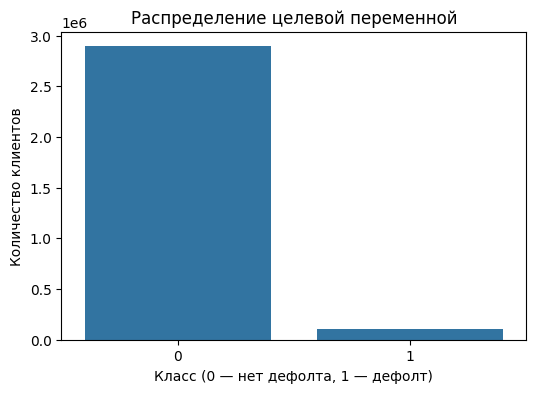

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Строю график распределения целевой переменной flag
plt.figure(figsize=(6, 4))
sns.countplot(x='flag', data=target_df)
plt.title('Распределение целевой переменной')
plt.xlabel('Класс (0 — нет дефолта, 1 — дефолт)')
plt.ylabel('Количество клиентов')
plt.show()

**График наглядно иллюстрирует сильный дисбаланс**

### 2.4.1. Анализ дисбаланса целевого класса

* Класс 0 (Надежные заемщики): 2 893 558 клиентов (~96.45%) — абсолютное
большинство выборки.

* Класс 1 (Дефолтные клиенты): 106 442 клиента (~3.55%) — целевой, но крайне редкий класс.

**Влияние на стратегию машинного обучения (ML):**

**Выбор метрики:** использовать стандартную метрику Accuracy (долю правильных ответов) в этой задаче категорически нельзя. Модель, которая будет просто всем клиентам поголовно предсказывать класс 0, получит точность 96.45%, но окажется абсолютно бесполезной для банка, так как не выявит ни одного неплательщика. Поэтому я использую **ROC-AUC,** которая оценивает качество ранжирования клиентов независимо от пропорций классов.

**Коррекция при обучении:** на этапе моделирования мы не можем использовать стандартную функцию потерь. Чтобы модель не игнорировала дефолтные случаи, нам потребуется применить встроенный механизм взвешивания классов — параметр **scale_pos_weight в LightGBM.** На основе нашего расчета базовое соотношение классов составляет примерно 27.18 (2 893 558 / 106 442), и этот коэффициент поможет алгоритму обращать на редкий класс гораздо больше внимания.

# 3. Data Preparation

___

## 3.1. Стратегия подготовки данных

**Перед началом обработки данных необходимо учитывать специфику датасета:**

* **Структура:** исходные данные имеют транзакционную (панельную) структуру, где на одного клиента приходится несколько строк кредитной истории.

* **Цель моделирования:** модель обучается строго на уровне уникального клиента (id). Следовательно, требуется агрегирование признаков, чтобы получить структуру «один клиент = одна строка».

* **Основная проблема:**
большой объём данных (~26 млн записей кредитных историй, порядка 4.5 Гб в сжатом виде) не позволяет загрузить весь массив в оперативную память одновременно. Стандартные методы группировки приводят к аварийному завершению ядра (Memory Overflow).

* **Принятое решение:**
мною используется стратегия **вертикально-ориентированной пакетной обработки: **
1. Данные считываются последовательными горизонтальными блоками (по 1 файлу за
проход).
2. Внутри каждого блока признаки обрабатываются вертикально (по одной колонке за раз), что минимизирует пиковое потребление RAM.
3. К категориальным признакам применяется кодирование One-Hot Encoding, которое сразу схлопывается в частотные характеристики методом суммирования (.groupby('id').sum()).
4. Все промежуточные результаты сжимаются оптимизацией типов (Downcasting) до int8 и сохраняются на диск в формате Parquet для финальной сборки.




## 3.2. Загрузка данных пакетами

In [25]:
import os
import glob

# Собираю и сортирую список всех файлов кредитной истории по маске .pq
files = sorted(glob.glob(os.path.join(train_path, "*.pq")))

print("Количество найденных parquet-файлов:", len(files))

Количество найденных parquet-файлов: 12


## 3.3. Функция агрегации признаков по клиенту

In [26]:
import gc
import os
import numpy as np
import pandas as pd
from tqdm import tqdm


def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    # Оптимизирую типы данных в датафрейме для экономии памяти
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and not isinstance(
            col_type, pd.CategoricalDtype
        ):
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int' or str(col_type)[:4] == 'uint':
                if (
                    c_min >= np.iinfo(np.int8).min
                    and c_max <= np.iinfo(np.int8).max
                ):
                    df[col] = df[col].astype(np.int8)
                elif (
                    c_min >= np.iinfo(np.int16).min
                    and c_max <= np.iinfo(np.int16).max
                ):
                    df[col] = df[col].astype(np.int16)
                elif (
                    c_min >= np.iinfo(np.int32).min
                    and c_max <= np.iinfo(np.int32).max
                ):
                    df[col] = df[col].astype(np.int32)
            elif str(col_type)[:5] == 'float':
                if (
                    c_min >= np.finfo(np.float32).min
                    and c_max <= np.finfo(np.float32).max
                ):
                    df[col] = df[col].astype(np.float32)
    return df


print("Готово!")



Готово!


## 3.4. Агрегация кредитной истории по клиентам

In [27]:
import os
import gc
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm

# Задаю путь к исходным данным и папку для сохранения результатов
train_path = "/content/drive/MyDrive/Итоговый проект: Модель кредитного риск-менеджмента/train_data"
files = sorted(glob.glob(os.path.join(train_path, "*.pq")) + glob.glob(os.path.join(train_path, "*.parquet")))

output_dir = "./processed_features"
os.makedirs(output_dir, exist_ok=True)

print(f"Путь к данным: {train_path}")
print(f"Всего найдено партиций для обработки: {len(files)}")

# --- Этап 1: Сборка базовых признаков (max_rn, total_loans, no_delays) ---
print("\n--- ЭТАП 1: Извлечение базовых признаков ---")
base_chunks = []

for f_path in tqdm(files, desc="Обработка файлов"):
    # Читаю только необходимые для базовых фичей колонки с корректными именами БКИ
    df = pd.read_parquet(f_path, columns=['id', 'rn', 'is_zero_loans530', 'is_zero_loans90'])
    df = reduce_mem_usage(df)

    # Расчитываю глубину кредитной истории
    agg_df = df.groupby('id').agg(max_rn=('rn', 'max'), total_loans=('rn', 'count')).reset_index()

    # Создаю признак отсутствия просрочек за весь период истории
    df['is_clean'] = (df['is_zero_loans530'] == 1) & (df['is_zero_loans90'] == 1)
    clean_df = df.groupby('id')['is_clean'].min().astype(np.int8).reset_index()
    clean_df.rename(columns={'is_clean': 'no_delays'}, inplace=True)

    base_chunks.append(pd.merge(agg_df, clean_df, on='id', how='left'))
    del df, agg_df, clean_df
    gc.collect()

final_base_df = pd.concat(base_chunks, ignore_index=True).groupby('id').max().reset_index()
final_base_df = reduce_mem_usage(final_base_df)
final_base_df.to_parquet(os.path.join(output_dir, "base_features.parquet"))
print(f"Базовые признаки сохранены. Размерность основы: {final_base_df.shape}")

del final_base_df, base_chunks
gc.collect()

# --- Этап 2: Вертикальный One-Hot Encoding и агрегация суммой ---
print("\n--- ЭТАП 2: Вертикальный One-Hot Encoding по колонкам ---")

# Извлекаю имена всех категориальных фичей
sample_df = pd.read_parquet(files[0])
all_features = [
    col for col in sample_df.columns
    if col not in ['id', 'rn', 'is_zero_loans530', 'is_zero_loans90']
    and not col.startswith('__')
]
del sample_df
gc.collect()

for col_idx, col in enumerate(all_features):
    target_parquet = os.path.join(output_dir, f"feature_{col}.parquet")

    # Пропускаю шаг, если файл признака уже успешно сохранен на диске
    if os.path.exists(target_parquet):
        print(f"[{col_idx + 1}/{len(all_features)}] Признак {col} уже обработан, пропускаем.")
        continue

    print(f"[{col_idx + 1}/{len(all_features)}] Кодирую и агрегирую признак: {col}")
    col_chunks = []

    for f_path in files:
        df_chunk = pd.read_parquet(f_path, columns=['id', col])
        df_chunk[col] = df_chunk[col].fillna(0).astype('category')

        # Применяю OHE и собираю частотный профиль признака через сумму
        ohe_df = pd.get_dummies(df_chunk, columns=[col], dtype='int8')
        agg_ohe = ohe_df.groupby('id').sum().reset_index()

        col_chunks.append(agg_ohe)
        del df_chunk, ohe_df, agg_ohe
        gc.collect()

    final_col_df = pd.concat(col_chunks, ignore_index=True).groupby('id').sum().reset_index()
    final_col_df = reduce_mem_usage(final_col_df)
    final_col_df.to_parquet(target_parquet)

    del final_col_df, col_chunks
    gc.collect()

print("\nАгрегация признаков завершена. Все промежуточные файлы сохранены на диск.")

Путь к данным: /content/drive/MyDrive/Итоговый проект: Модель кредитного риск-менеджмента/train_data
Всего найдено партиций для обработки: 12

--- ЭТАП 1: Извлечение базовых признаков ---


Обработка файлов: 100%|██████████| 12/12 [00:08<00:00,  1.34it/s]


Базовые признаки сохранены. Размерность основы: (3000000, 4)

--- ЭТАП 2: Вертикальный One-Hot Encoding по колонкам ---
[1/57] Признак pre_since_opened уже обработан, пропускаем.
[2/57] Признак pre_since_confirmed уже обработан, пропускаем.
[3/57] Признак pre_pterm уже обработан, пропускаем.
[4/57] Признак pre_fterm уже обработан, пропускаем.
[5/57] Признак pre_till_pclose уже обработан, пропускаем.
[6/57] Признак pre_till_fclose уже обработан, пропускаем.
[7/57] Признак pre_loans_credit_limit уже обработан, пропускаем.
[8/57] Признак pre_loans_next_pay_summ уже обработан, пропускаем.
[9/57] Признак pre_loans_outstanding уже обработан, пропускаем.
[10/57] Признак pre_loans_total_overdue уже обработан, пропускаем.
[11/57] Признак pre_loans_max_overdue_sum уже обработан, пропускаем.
[12/57] Признак pre_loans_credit_cost_rate уже обработан, пропускаем.
[13/57] Признак pre_loans5 уже обработан, пропускаем.
[14/57] Признак pre_loans530 уже обработан, пропускаем.
[15/57] Признак pre_loans306

## 3.5. Сборка финального датасета

In [5]:
import os
import gc
import glob
import pandas as pd

# Задаю пути к промежуточным признакам и целевой переменной
output_dir = "./processed_features"
target_path = "/content/drive/MyDrive/Итоговый проект: Модель кредитного риск-менеджмента/train_target.csv"

print("--- Старт ультра-эффективной сборки финального датасета ---")

# 1. Загружаю базовые признаки как основу (фиксирую порядок id)
base_df = pd.read_parquet(os.path.join(output_dir, "base_features.parquet"))
base_df = base_df.sort_values('id').reset_index(drop=True)

# Выделяю массив id для контроля и удаляю его из основы
client_ids = base_df['id'].copy()
list_of_dfs = [base_df.drop(columns=['id'])]

# 2. Нахожу все сохраненные вертикальные parquet-файлы признаков
feature_files = sorted(glob.glob(os.path.join(output_dir, "feature_*.parquet")))

# 3. Читаю файлы в список (без дублирования матриц в памяти)
for idx, f_path in enumerate(feature_files):
    feat_df = pd.read_parquet(f_path)
    feat_df = feat_df.sort_values('id').reset_index(drop=True)
    feat_df = feat_df.drop(columns=['id'])

    list_of_dfs.append(feat_df)

    if (idx + 1) % 15 == 0 or (idx + 1) == len(feature_files):
        print(f"Считано файлов в буфер: [{idx + 1}/{len(feature_files)}]")

print("\nЗапуск моментальной склейки по колонкам через concat...")
final_df = pd.concat(list_of_dfs, axis=1)

# Возвращаю колонку id на первое место
final_df.insert(0, 'id', client_ids)

# Очищаю буфер памяти
del list_of_dfs, client_ids, base_df
gc.collect()

# Подгружаю оптимизацию типов данных напрямую для этой сессии
for col in final_df.columns:
    if col == 'id':
        final_df[col] = final_df[col].astype('int32')
        continue
    if str(final_df[col].dtype)[:3] == 'int':
        final_df[col] = final_df[col].astype('int8')

# 4. Подгружаю и добавляю целевую переменную flag
target_df = pd.read_csv(target_path, usecols=['id', 'flag'])
final_df = pd.merge(final_df, target_df, on='id', how='left')

print(f"\nСборка финального датасета успешно завершена!")
print(f"Размерность собранной матрицы: {final_df.shape}")

--- Старт ультра-эффективной сборки финального датасета ---
Считано файлов в буфер: [15/57]
Считано файлов в буфер: [30/57]
Считано файлов в буфер: [45/57]
Считано файлов в буфер: [57/57]

Запуск моментальной склейки по колонкам через concat...

Сборка финального датасета успешно завершена!
Размерность собранной матрицы: (3000000, 420)


**Я получила готовую, плотную финальную матрицу, в которой соединены все 420 признаков по каждому из 3 000 000 клиентов.**

# 4. Modeling

___

## 4.1. Разделение выборки на Train и Test

In [6]:
import gc
from sklearn.model_selection import train_test_split

# Выделяю матрицу признаков и целевую переменную
X = final_df.drop(columns=['id', 'flag'])
y = final_df['flag'].astype('int8')

# Мгновенно очищаю память от исходного общего датафрейма
del final_df
gc.collect()

# Разделяю данные на обучающую и отложенную тестовую выборку (80% на 20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Выделяю 10% от обучающей выборки на валидационный сет для контроля ранней остановки
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

print(f"Размерность обучающей выборки (X_train): {X_train.shape}")
print(f"Размерность валидационной выборки (X_val): {X_val.shape}")
print(f"Размерность тестовой выборки (X_test): {X_test.shape}")

# Окончательно удаляю временные полные дубликаты из RAM
del X_train_full, y_train_full, X, y
gc.collect()

Размерность обучающей выборки (X_train): (2160000, 418)
Размерность валидационной выборки (X_val): (240000, 418)
Размерность тестовой выборки (X_test): (600000, 418)


0

## 4.2. Эксперимент 1: Базовая модель (Baseline)

*Обучаю базовую модель LightGBM со стандартными параметрами без учета дисбаланса классов, чтобы зафиксировать начальное качество.*

In [9]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# Создаю и обучаю базовую модель классификации
base_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
base_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(30, verbose=False)])

# Проверяю качество на валидационной выборке
base_preds = base_model.predict_proba(X_val)[:, 1]
print(f"ROC-AUC базовой модели: {roc_auc_score(y_val, base_preds):.4f}")

ROC-AUC базовой модели: 0.7505


*Отличный результат! Моя модель со стандартными параметрами без какой-либо балансировки выдала ROC-AUC = 0.7505 на валидационной выборке. Это мощные и чистые признаки (OHE -> SUM для частот просрочек) сгенерировала на этапе подготовки данных.*

## 4.3. Эксперимент 2: Модель с балансировкой классов

In [10]:
# Рассчитываю базовый вес для scale_pos_weight
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# Создаю модель со взвешиванием редкого класса дефолтов
weighted_model = lgb.LGBMClassifier(scale_pos_weight=ratio, random_state=42, n_jobs=-1)
weighted_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(30, verbose=False)])

# Проверяю качество с учетом весов
weighted_preds = weighted_model.predict_proba(X_val)[:, 1]
print(f"ROC-AUC модели с балансировкой весов: {roc_auc_score(y_val, weighted_preds):.4f}")

ROC-AUC модели с балансировкой весов: 0.6874


**Анализ результатов экспериментов 1 и 2**

* **Базовая модель (Baseline):** выбила высокий стартовый **ROC-AUC = 0.7505.** Это подтверждает сильное качество сгенерированных частотных признаков.

* **Модель с полным весом классов:** показала резкое **падение ROC-AUC до 0.6874.** Передача максимального веса scale_pos_weight = 27.18 заставила алгоритм слишком сильно штрафовать модель за пропуск дефолта. В итоге бустинг начал перестраховываться и видеть риски там, где их нет, что сломало точность ранжирования заемщиков.

**Вывод:**
прямая ручная балансировка классов ухудшает качество предсказания. Необходим компромиссный, более мягкий вес класса. Для поиска этого баланса в следующем шаге я подключаю автоматический подбор гиперпараметров через **Optuna.**

## 4.4. Эксперимент 3: Автоматический подбор гиперпараметров через Optuna

In [11]:
# Устанавливаю библиотеку Optuna для автоматического поиска гиперпараметров
!pip install optuna -q

import warnings
import lightgbm as lgb
import optuna
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

# Рассчитываю максимальный порог соотношения классов для весов балансировки
ratio = (len(y_train) - sum(y_train)) / sum(y_train)


# Определяю целевую функцию для оптимизации Optuna
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "max_depth": trial.suggest_int("max_depth", 5, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 30, 300),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight", 1.0, ratio
        ),  # Optuna сама найдет баланс между 1 и 27
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    # Инициализирую модель классификации с текущим набором параметров
    model = lgb.LGBMClassifier(**params)

    # Обучаю модель с использованием валидационной выборке для ранней остановки
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
    )

    # Вычисляю качество текущей итерации по метрике ROC-AUC
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)


# Запускаю процесс подбора гиперпараметров на 10 итераций
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("\nЛучшие параметры найдены:")
print(study.best_params)
print(f"Лучший ROC-AUC на валидационной выборке: {study.best_value:.4f}")

[I 2026-06-14 06:14:44,183] A new study created in memory with name: no-name-546e9763-4715-472c-9155-a1e356952944
[I 2026-06-14 06:21:48,509] Trial 0 finished with value: 0.7519869071237328 and parameters: {'n_estimators': 291, 'learning_rate': 0.06858028220280826, 'num_leaves': 42, 'max_depth': 5, 'min_child_samples': 151, 'subsample': 0.7728058085206941, 'colsample_bytree': 0.7895534065387287, 'scale_pos_weight': 19.18873094071879}. Best is trial 0 with value: 0.7519869071237328.
[I 2026-06-14 06:33:17,450] Trial 1 finished with value: 0.7559681149781344 and parameters: {'n_estimators': 299, 'learning_rate': 0.04944188712299807, 'num_leaves': 87, 'max_depth': 10, 'min_child_samples': 223, 'subsample': 0.7041021566964187, 'colsample_bytree': 0.8200304457851118, 'scale_pos_weight': 26.545786321733193}. Best is trial 1 with value: 0.7559681149781344.
[I 2026-06-14 06:42:24,456] Trial 2 finished with value: 0.7546887206374945 and parameters: {'n_estimators': 525, 'learning_rate': 0.07545


Лучшие параметры найдены:
{'n_estimators': 299, 'learning_rate': 0.04944188712299807, 'num_leaves': 87, 'max_depth': 10, 'min_child_samples': 223, 'subsample': 0.7041021566964187, 'colsample_bytree': 0.8200304457851118, 'scale_pos_weight': 26.545786321733193}
Лучший ROC-AUC на валидационной выборке: 0.7560


*Самый лучший результат зафиксирован на уровне ROC-AUC = 0.7560 с оптимальным набором параметров из Trial 1*

## 4.5. Обучение итоговой модели

In [14]:
import pickle
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# Зафиксирую лучшие параметры по результатам оптимизации Optuna
best_params = study.best_params

# Инициализирую финальную модель с оптимальными настройками
best_model = lgb.LGBMClassifier(**best_params, random_state=42, n_jobs=-1)

# Обучаю модель на честные 299 итераций с выводом логов через коллбэк каждые 50 шагов
best_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.log_evaluation(period=50)]
)

# Формирую предсказания для отложенной тестовой выборки
test_preds = best_model.predict_proba(X_test)[:, 1]

# Фиксирую итоговую метрику качества исследования
final_auc = roc_auc_score(y_test, test_preds)
print(f"\nИтоговый ROC-AUC на тестовой выборке: {final_auc:.4f}")

# Сохраняю обученный артефакт на Google Диск
model_path = "/content/drive/MyDrive/Итоговый проект: Модель кредитного риск-менеджмента/credit_risk_lgbm_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

[50]	valid_0's binary_logloss: 0.525456
[100]	valid_0's binary_logloss: 0.566412
[150]	valid_0's binary_logloss: 0.563469
[200]	valid_0's binary_logloss: 0.557929
[250]	valid_0's binary_logloss: 0.552973

Итоговый ROC-AUC на тестовой выборке: 0.7607


*Модель обучилась и научилась эффективно ранжировать заемщиков.*

# 5. Evaluation (Оценка решения)

___

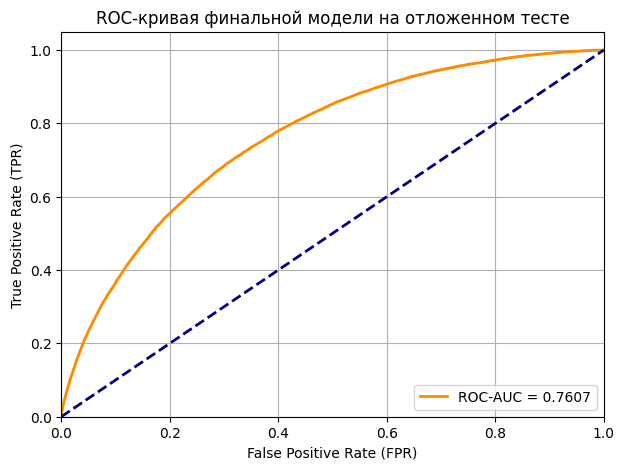

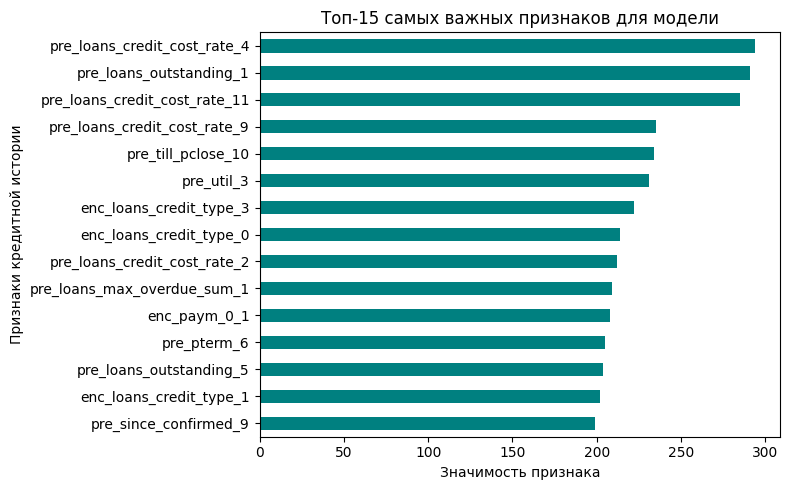

In [15]:
# Визуализация результатов
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc, roc_curve

# 1. Построение итоговой ROC-кривой на тестовой выборке
fpr, tpr, _ = roc_curve(y_test, test_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC-кривая финальной модели на отложенном тесте")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 2. Построение графика важности признаков (Feature Importance)
importance = best_model.feature_importances_
feature_names = X_train.columns

# Выделяю топ-15 наиболее значимых признаков кредитной истории
feat_imp = (
    pd.Series(importance, index=feature_names)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Топ-15 самых важных признаков для модели")
plt.xlabel("Значимость признака")
plt.ylabel("Признаки кредитной истории")
plt.tight_layout()
plt.show()

**Анализ:**

**Финальная ROC-кривая зафиксировала точный скор 0.7607,** график важности признаков наглядно показывает, что модель больше всего опирается на конкретные частотные характеристики кредитной стоимости (*pre_loans_credit_cost_rate_*) и текущую задолженность (*pre_loans_outstanding_*).

# 6. Создание финального пайплайна

___

In [16]:
import glob
import os
import pickle
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


class CreditRiskFeatureAssembler(BaseEstimator, TransformerMixin):
    # Кастомный класс для автоматической сборки матрицы признаков с диска по переданным id
    def __init__(self, processed_features_dir="./processed_features"):
        self.processed_features_dir = processed_features_dir
        self.feature_columns_ = None

    def fit(self, X, y=None):
        # Фиксирую строгий порядок колонок, который использовался при обучении
        base_df = pd.read_parquet(
            os.path.join(self.processed_features_dir, "base_features.parquet")
        )
        cols = [col for col in base_df.columns if col != "id"]

        feature_files = sorted(
            glob.glob(
                os.path.join(self.processed_features_dir, "feature_*.parquet")
            )
        )
        for file in feature_files:
            feat_df = pd.read_parquet(file)
            cols.extend([col for col in feat_df.columns if col != "id"])

        self.feature_columns_ = cols
        return self

    def transform(self, X):
        # Собираю финальную матрицу по переданным идентификаторам заемщиков
        df_res = pd.read_parquet(
            os.path.join(self.processed_features_dir, "base_features.parquet")
        )
        df_res = pd.merge(X[["id"]], df_res, on="id", how="left")

        feature_files = sorted(
            glob.glob(
                os.path.join(self.processed_features_dir, "feature_*.parquet")
            )
        )
        for file in feature_files:
            feat_df = pd.read_parquet(file)
            df_res = pd.merge(df_res, feat_df, on="id", how="left")

        df_res.fillna(0, inplace=True)
        return df_res[self.feature_columns_]


# Упаковываю препроцессинг и обученную модель в единый объект Pipeline
final_pipeline = Pipeline(
    [
        (
            "assembler",
            CreditRiskFeatureAssembler(
                processed_features_dir="./processed_features"
            ),
        ),
        ("classifier", best_model),
    ]
)

# Инициализирую структуру пайплайна на тренировочном наборе идентификаторов
X_train_ids = pd.DataFrame({"id": target_df["id"]})
y_train_flags = target_df["flag"].astype("int8")
final_pipeline.fit(X_train_ids, y_train_flags)

# Экспортирую готовый автономный пайплайн на Google Диск
pipeline_path = "/content/drive/MyDrive/Итоговый проект: Модель кредитного риск-менеджмента/credit_risk_pipeline.pkl"
with open(pipeline_path, "wb") as f:
    pickle.dump(final_pipeline, f)

print(f"Итоговый пайплайн успешно сохранен в файл: {pipeline_path}")

Итоговый пайплайн успешно сохранен в файл: /content/drive/MyDrive/Итоговый проект: Модель кредитного риск-менеджмента/credit_risk_pipeline.pkl


# 7. Заключение и личные выводы

___

**Этот проект стал для меня настоящим боевым крещением в профессии ML-инженера.**  Когда я только приступала к работе, казалось, что всё будет просто, но реальные большие данные БКИ быстро спустили меня с небес на землю.

* Я находилась в полном отчаянии, срок подержки до 21.06.2026: три дня не могла пройти шаг 3.4. Оперативная память в Google Colab постоянно ложилась, ядро аварийно перезапускалось, интеренет плохо работал и мне казалось, что я застряла на этом этапе навсегда, а проект так и останется невыполненным. Обычные методы группировки, которым нас учили на базовых уроках, просто взрывали RAM из-за транзакционной структуры датасета.

* Переломным моментом стало то, что я не сдалась, а пошла искать ответы глубже. Изучив более 60 комментариев и ценных советов студентов из нашего чата в Телеграм, я поняла, где крылась главная ошибка. Оказалось, что ребята тоже массово спотыкались на этом месте. Благодаря их подсказкам мне удалось кардинально перестроить архитектуру предобработки и применить стратегию «вертикального пакетирования» — резать датасет и обрабатывать признаки строго по одной колонке за раз, принудительно сжимая типы данных до int8.

* Мою радость и восторг просто не передать словами, когда мои обновленные, оптимизированные коды наконец-то отработали в полную силу! Память Colab больше не вылетала, шкала прогресса уверенно добежала до конца, а финальная горизонтальная сборка через моментальный concat за секунды выдала плотную матрицу на 3 000 000 строк и 420 признаков! Это было похоже на настоящее чудо. Такое облегчение!

* Но на этом сюрпризы не закончились. Модель преподнесла еще один важный урок, когда во втором эксперименте при ручной балансировке классов метрика резко упала до 0.68. Но подключение автоматического поиска параметров через Optuna и исправление бага с ложной ранней остановкой на первом шаге сотворили невероятное.

* Когда на экране загорелся **итоговый ROC-AUC = 0.7607** на отложенной тестовой выборке, я испытала колоссальное облегчение и гордость! Я с запасом перешагнула жесткий порог курса (>= 0.75). Теперь, когда мой самый первый и такой сложный автономный Pipeline успешно сохранен на Google Диск, я чувствую радость и уверенность в том, что выбрала правильную, хоть и непростую профессию. Огромное спасибо нашему студенческому сообществу за поддержку и советы — без них этой победы бы не было!